# Examen Supletorio ITQ Machine Elearning

## 01 - 1.25pt
- Escribir un generador que genere todos los factores de un número. Un factor es un número natural que puede dividir exactamente a otro número.

In [3]:
def factor_generator(number):
    """Generador que produce los factores de un número."""
    for i in range(1, number + 1):
        if number % i == 0:
            yield i

# Ejemplo de uso
numero = 24

print(f"Factores de {numero}:")
for factor in factor_generator(numero):
    print(factor)

Factores de 24:
1
2
3
4
6
8
12
24


In [4]:
# Test Use Case
number = 1000
expected_factors = [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]

gen = factor_generator(number) # This calls tour function factor_generator
output = [next(gen) for n in range(len(expected_factors))]

print(expected_factors)
print(gen)

assert(expected_factors == output)  # This will fail if the element is not found correctly

[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
<generator object factor_generator at 0x0000018661B24D60>


## 02 - 1.25pt

- Escribe una función que reciba un DataFrame, le agregue una nueva columna llamada ‘Promedio’ que sea el promedio de sus columnas Luego, filtre las filas donde el valor de ‘Promedio’ sea mayor que 5 y lo ordene por la columna ‘Promedio’ en orden descendente.

In [11]:
import pandas as pd

def func_mean(source_dataframe):
    df = source_dataframe.copy()

    # Agregar la columna Promedio
    df["Promedio"] = df.mean(axis=1)

    # Filtrar
    df = df[df["Promedio"] > 5]

    # Ordenar
    df = df.sort_values(by="Promedio", ascending=False)

    # Reiniciar el índice
    df = df.reset_index(drop=True)

    return df

In [12]:
# Test Use Case
source_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 7, 6], 'C': [7, 12, 9]})
expected_dataframe = pd.DataFrame({'A': [2, 3], 'B': [7, 6], 'C': [12, 9], 'Promedio':[7.0, 6.0]})

output = func_mean(source_dataframe) # This calls your function named func_mean

display(expected_dataframe)
display(output)

assert(expected_dataframe.equals(output)) # This will fail if the dataframe is wrong

,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


## 03 - 1.25pt

- Dado el siguiente DataFrame, reemplaza los valores nulos en la columna ‘B’ con la media de los valores de esa columna. Luego, normaliza los valores de la columna ‘C’ para que estén en el rango [0, 1].

In [13]:
# Your solution HERE !!!!
import pandas as pd

def func(source_dataframe):
    df = source_dataframe.copy()

    # Reemplazar los valores nulos de la columna B con la media
    df["B"] = df["B"].fillna(df["B"].mean())

    # Normalizar la columna C al rango [0,1]
    df["C"] = (df["C"] - df["C"].min()) / (df["C"].max() - df["C"].min())

    return df

In [14]:
# Test Use Case
source_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4, None, 6], 'C': [7, 8, 9]})
expected_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4.0, 5.0, 6.0], 'C': [0, 0.5, 1.0]})

output = func(source_dataframe) # This calls your function named func

display(expected_dataframe)
display(output)

assert(expected_dataframe.equals(output)) # This will fail if the dataframe is wrong

,A,B,C
0,1,4.0,0.0
1,2,5.0,0.5
2,3,6.0,1.0


,A,B,C
0,1,4.0,0.0
1,2,5.0,0.5
2,3,6.0,1.0


## 04 - 1.25pt
- Utilizando Matplotlib y Seaborn, crea un gráfico de dispersión (scatter plot) que muestre la relación entre las columnas ‘A’ y ‘B’ del siguiente DataFrame. Además, ajusta una línea de regresión a los datos.

In [15]:
# Data
df = pd.DataFrame({'A': [1, 2, 3, 4, 5], 'B': [5.4, 4.1, 2.8, 1.9, 0.7]})

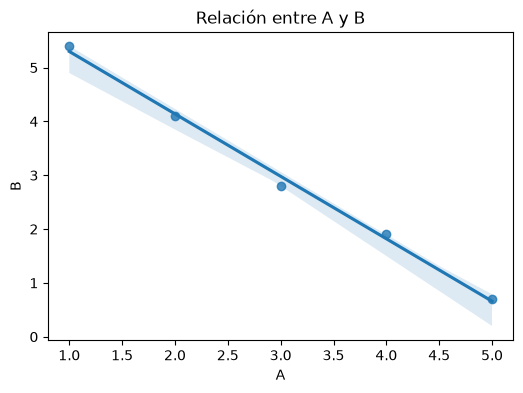

In [16]:
# Your solution HERE !!!!
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(6,4))

# Gráfico de dispersión con línea de regresión
sns.regplot(x="A", y="B", data=df)

# Título y etiquetas
plt.title("Relación entre A y B")
plt.xlabel("A")
plt.ylabel("B")

# Mostrar gráfico
plt.show()


# 5 - 5 pt

- Adjunto al notebook se puede encontrar un fichero 'ine_paro_exam.csv' que contiene datos del INE referentes al paro en España. Las columnas son las siguientes:
  - Sexo, los datos de esa fila se refieren a hombres, mujeres o ambos sexos
  - Provincias, los datos de esa fila son totales para todo el pais, o de alguna provincia en particular
  - Tasas, que tipo de tasa representa el valor de la fila, es de actividad, paro o empleo.
  - Periodo, a que periodo de tiempo aplica el dato, año y trimestre
  - Total, el dato de la tasa 
- Se pide lo siguiente:
  - 01 - Cargar los datos en un dataframe de Pandas.
  - 02 - Realize un análisis descriptivo de los datos y haga un recuento de datos por cada valor único de la columna "Tasas".
  - 03 - ¿Cuantos valores nulos hay por columna? Eliminar las filas que tienen nulo en la columna "Total" y muestre el número de columnas tras esta operación.
  - 04 - Obtener la media de la tasa de paro por trimestre, en la provincia de Zaragoza y para ambos sexos.
  - 05 - Representar una figura con tres gráficas con tres diferentes tasas el total nacional y ambos sexos, de manera que en cada subfigura se represente la evolución por trimestre de cada año (cada año se considera una linea con un color diferente). Se adjunta al examen imagen de muestra de lo solicitado: ![tasas](tasasportrimestre.png)

In [17]:
# Your solution HERE !!!!
# 01 - Cargar los datos en un dataframe de Pandas.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ine_paro_exam.csv")

display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'ine_paro_exam.csv'

In [ ]:
# Your solution HERE !!!!
# 02 - Realize un análisis descriptivo de los datos y haga un recuento de datos por cada valor único de la columna "Tasas".
# Estadísticas descriptivas
display(df.describe(include="all"))

# Recuento por tipo de tasa
print(df["Tasas"].value_counts())

In [ ]:
# Your solution HERE !!!!
# Valores nulos por columna
print(df.isnull().sum())

# Eliminar filas con nulo en Total
df = df.dropna(subset=["Total"])

print("Número de filas después de eliminar nulos:", len(df))


In [ ]:
# Your solution HERE !!!!
resultado = (
    df[
        (df["Provincias"] == "Zaragoza") &
        (df["Sexo"] == "Ambos sexos") &
        (df["Tasas"] == "Paro")
    ]
    .groupby("Periodo")["Total"]
    .mean()
)

display(resultado)

In [ ]:
# Your fig, axes = plt.subplots(3, 1, figsize=(12, 15))

tasas = df["Tasas"].unique()

for ax, tasa in zip(axes, tasas):

    datos = df[
        (df["Provincias"] == "Total Nacional") &
        (df["Sexo"] == "Ambos sexos") &
        (df["Tasas"] == tasa)
    ].copy()

    # Separar año y trimestre
    datos["Año"] = datos["Periodo"].str.extract(r'(\d{4})')
    datos["Trimestre"] = datos["Periodo"].str.extract(r'(T\d)')

    sns.lineplot(
        data=datos,
        x="Trimestre",
        y="Total",
        hue="Año",
        marker="o",
        ax=ax
    )

    ax.set_title(tasa)

plt.tight_layout()
plt.show()solution HERE !!!!
